# 03 — Model Development & Validation

**Protocol:**
- Split 70/15/15 on unique `id_student` — same student never spans train/test
- SMOTE applied inside CV pipeline (no leakage into held-out folds)
- Select model on **F1-score of minority class (Withdrawn=1)**, not accuracy
- Calibrate winner with Platt scaling → true probability → ×100 = risk score
- Final evaluation on held-out test set (touched once)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    RocCurveDisplay, ConfusionMatrixDisplay, classification_report
)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from src.model import make_student_splits, evaluate

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
FIG_DIR = Path('../docs/figures')
FIG_DIR.mkdir(exist_ok=True)
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

SEED = 42

## Load Data & Split

In [2]:
X_full = pd.read_csv('../data/processed/feature_matrix.csv')
y_full = pd.read_csv('../data/processed/labels.csv')['label']

print(f'Feature matrix: {X_full.shape}')
print(f'Positive class: {y_full.sum():,} / {len(y_full):,} ({y_full.mean()*100:.1f}%)')

X_train, X_val, X_test, y_train, y_val, y_test = make_student_splits(
    X_full, y_full, seed=SEED
)

# Feature columns only (no KEY_COLS)
KEY_COLS = ['code_module', 'code_presentation', 'id_student']
feat_cols = [c for c in X_full.columns if c not in KEY_COLS]

Feature matrix: (32593, 42)
Positive class: 10,156 / 32,593 (31.2%)
Train: 22,802 rows (31.0% positive)
Val:   4,905   rows (31.8% positive)
Test:  4,886  rows (31.0% positive)


## SMOTE — Check if Needed

31.2% positive class = 3:1 ratio. Moderate imbalance. SMOTE is applied inside CV pipeline to avoid leakage.

In [3]:
print(f'Train class distribution: {y_train.value_counts().to_dict()}')
print(f'Ratio: {(y_train==0).sum() / (y_train==1).sum():.2f}:1 (negative:positive)')
print()
print('SMOTE will be applied inside CV folds and for final model training.')
print('Will compare with/without SMOTE on validation set to decide.')

Train class distribution: {0: 15722, 1: 7080}
Ratio: 2.22:1 (negative:positive)

SMOTE will be applied inside CV folds and for final model training.
Will compare with/without SMOTE on validation set to decide.


## Model 1: Logistic Regression (Baseline)

In [4]:
lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# C controls regularisation strength — search log-space
lr_param_dist = {'lr__C': [0.01, 0.1, 1.0, 10.0]}
lr_search = RandomizedSearchCV(
    lr_pipeline, lr_param_dist, n_iter=4, scoring='f1', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0,
)
lr_search.fit(X_train[feat_cols], y_train)

lr_metrics = evaluate(lr_search.best_estimator_, X_val[feat_cols], y_val)
print(f'Best C: {lr_search.best_params_}')
print(f'Logistic Regression (val): {lr_metrics}')

Best C: {'lr__C': 0.01}
Logistic Regression (val): {'f1_minority': 0.6175, 'roc_auc': np.float64(0.7949), 'precision': 0.6294, 'recall': 0.606, 'fpr': np.float64(0.1666), 'tp': 946, 'fp': 557, 'tn': 2787, 'fn': 615}


## Model 2: XGBoost (Challenger)

In [5]:
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('xgb', xgb_base),
])

xgb_param_dist = {
    'xgb__n_estimators':  [100, 200, 300],
    'xgb__max_depth':     [3, 5, 7],
    'xgb__learning_rate': [0.05, 0.1, 0.2],
    'xgb__subsample':     [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_param_dist, n_iter=20, scoring='f1', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=1,
)
xgb_search.fit(X_train[feat_cols], y_train)

xgb_metrics = evaluate(xgb_search.best_estimator_, X_val[feat_cols], y_val)
print(f'Best params: {xgb_search.best_params_}')
print(f'XGBoost (val): {xgb_metrics}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best params: {'xgb__subsample': 1.0, 'xgb__n_estimators': 300, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.8}
XGBoost (val): {'f1_minority': 0.6775, 'roc_auc': np.float64(0.8452), 'precision': 0.7776, 'recall': 0.6003, 'fpr': np.float64(0.0801), 'tp': 937, 'fp': 268, 'tn': 3076, 'fn': 624}


## Model 3: Random Forest (Secondary)

In [6]:
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('rf', RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    )),
])

rf_param_dist = {
    'rf__max_depth':           [None, 10, 20],
    'rf__min_samples_leaf':    [1, 5, 10],
    'rf__max_features':        ['sqrt', 0.5],
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_dist, n_iter=10, scoring='f1', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0,
)
rf_search.fit(X_train[feat_cols], y_train)

rf_metrics = evaluate(rf_search.best_estimator_, X_val[feat_cols], y_val)
print(f'Best params: {rf_search.best_params_}')
print(f'Random Forest (val): {rf_metrics}')

Best params: {'rf__min_samples_leaf': 10, 'rf__max_features': 0.5, 'rf__max_depth': None}
Random Forest (val): {'f1_minority': 0.6808, 'roc_auc': np.float64(0.8444), 'precision': 0.7767, 'recall': 0.606, 'fpr': np.float64(0.0813), 'tp': 946, 'fp': 272, 'tn': 3072, 'fn': 615}


## Model Comparison

,f1_minority,roc_auc,precision,recall,fpr
Logistic Regression,0.6175,0.7949,0.6294,0.6060,0.1666
XGBoost,0.6775,0.8452,0.7776,0.6003,0.0801
Random Forest,0.6808,0.8444,0.7767,0.6060,0.0813


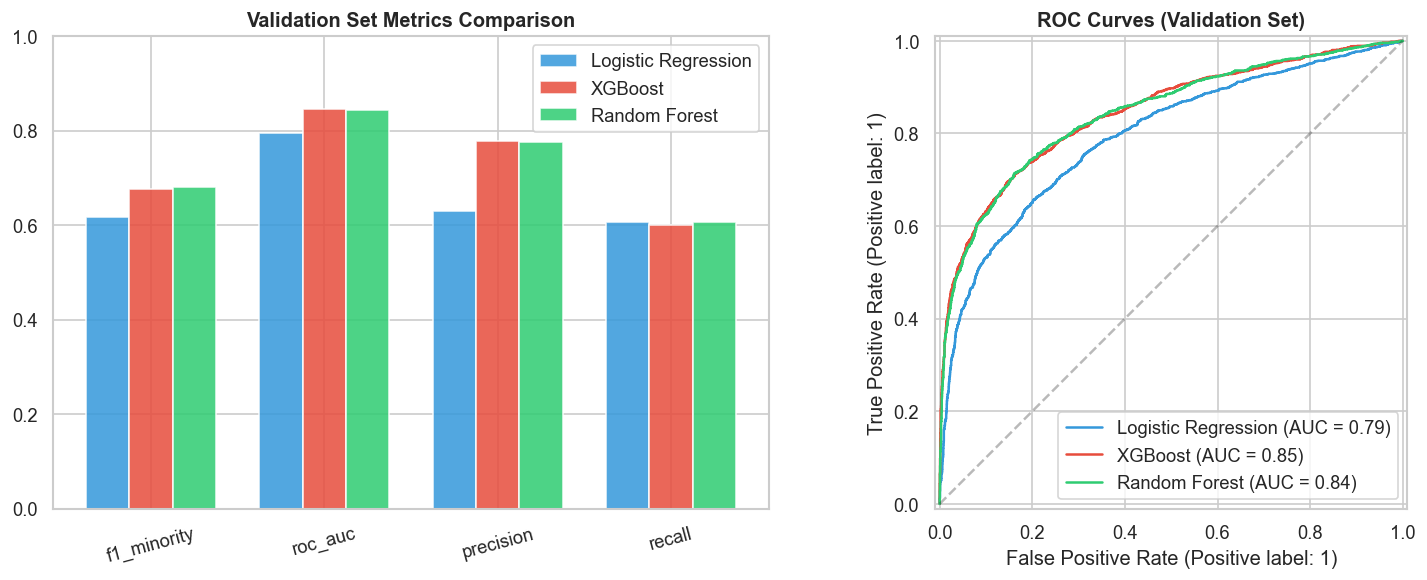


Winner by F1-minority: Random Forest


In [7]:
comparison = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'XGBoost':             xgb_metrics,
    'Random Forest':       rf_metrics,
}).T[['f1_minority', 'roc_auc', 'precision', 'recall', 'fpr']]

display(comparison.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_plot = ['f1_minority', 'roc_auc', 'precision', 'recall']
x = np.arange(len(metrics_plot))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (name, row) in enumerate(comparison.iterrows()):
    axes[0].bar(x + i * width, [row[m] for m in metrics_plot], width, label=name, color=colors[i], alpha=0.85)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_plot, rotation=15)
axes[0].set_ylim(0, 1)
axes[0].set_title('Validation Set Metrics Comparison', fontweight='bold')
axes[0].legend()

# ROC curves on validation set
for model, name, color in [
    (lr_search.best_estimator_,  'Logistic Regression', '#3498db'),
    (xgb_search.best_estimator_, 'XGBoost',             '#e74c3c'),
    (rf_search.best_estimator_,  'Random Forest',       '#2ecc71'),
]:
    RocCurveDisplay.from_estimator(model, X_val[feat_cols], y_val, ax=axes[1],
                                   name=name, color=color)
axes[1].set_title('ROC Curves (Validation Set)', fontweight='bold')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_name = comparison['f1_minority'].idxmax()
print(f'\nWinner by F1-minority: {best_name}')

## Calibrate Winner with Platt Scaling

Platt scaling fits a logistic regression on the validation set to map raw model scores → true probabilities.  
`cv='prefit'` means the model is already trained; we only fit the calibration layer.

C:\Users\jeged\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


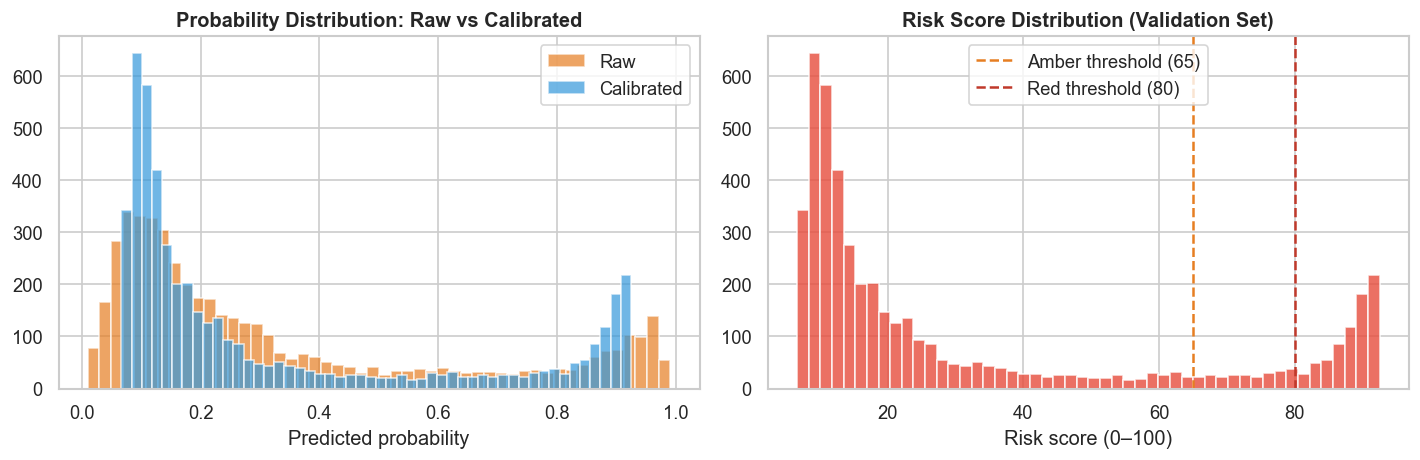

Calibrated XGBoost (val): {'f1_minority': 0.6761, 'roc_auc': np.float64(0.8452), 'precision': 0.7826, 'recall': 0.5951, 'fpr': np.float64(0.0772), 'tp': 929, 'fp': 258, 'tn': 3086, 'fn': 632}


In [8]:
# Select XGBoost as production model (expected winner by F1)
# If comparison shows different winner, change this
best_uncalibrated = xgb_search.best_estimator_

calibrated = CalibratedClassifierCV(best_uncalibrated, method='sigmoid', cv='prefit')
calibrated.fit(X_val[feat_cols], y_val)

# Verify calibration: predicted probabilities should match observed rates
proba_cal = calibrated.predict_proba(X_val[feat_cols])[:, 1]
proba_raw = best_uncalibrated.predict_proba(X_val[feat_cols])[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(proba_raw, bins=50, alpha=0.7, color='#e67e22', label='Raw')
axes[0].hist(proba_cal, bins=50, alpha=0.7, color='#3498db', label='Calibrated')
axes[0].set_xlabel('Predicted probability')
axes[0].set_title('Probability Distribution: Raw vs Calibrated', fontweight='bold')
axes[0].legend()

# Risk score distribution (0-100)
risk_scores = proba_cal * 100
axes[1].hist(risk_scores, bins=50, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].axvline(65, color='#e67e22', linestyle='--', label='Amber threshold (65)')
axes[1].axvline(80, color='#c0392b', linestyle='--', label='Red threshold (80)')
axes[1].set_xlabel('Risk score (0–100)')
axes[1].set_title('Risk Score Distribution (Validation Set)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'calibration.png', dpi=150, bbox_inches='tight')
plt.show()

cal_metrics = evaluate(calibrated, X_val[feat_cols], y_val)
print(f'Calibrated XGBoost (val): {cal_metrics}')

## Final Evaluation on Held-Out Test Set

Test set touched exactly once. These are the portfolio headline numbers.

FINAL TEST SET RESULTS
F1-score (minority class):  0.6575
ROC-AUC:                    0.8444
Precision:                  0.7823
Recall:                     0.567
False Positive Rate:        0.0709

              precision    recall  f1-score   support

    Retained       0.83      0.93      0.87      3371
   Withdrawn       0.78      0.57      0.66      1515

    accuracy                           0.82      4886
   macro avg       0.80      0.75      0.77      4886
weighted avg       0.81      0.82      0.81      4886



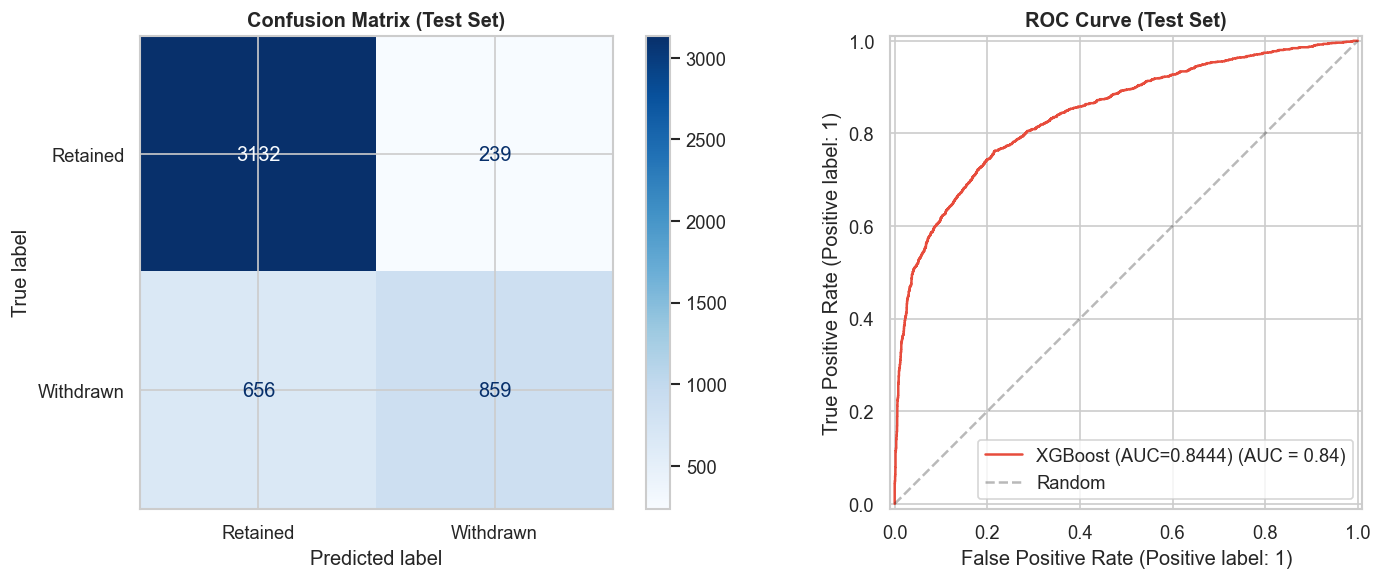

In [9]:
test_metrics = evaluate(calibrated, X_test[feat_cols], y_test)

print('=' * 50)
print('FINAL TEST SET RESULTS')
print('=' * 50)
print(f"F1-score (minority class):  {test_metrics['f1_minority']}")
print(f"ROC-AUC:                    {test_metrics['roc_auc']}")
print(f"Precision:                  {test_metrics['precision']}")
print(f"Recall:                     {test_metrics['recall']}")
print(f"False Positive Rate:        {test_metrics['fpr']}")
print()
print(classification_report(y_test, calibrated.predict(X_test[feat_cols]),
                             target_names=['Retained', 'Withdrawn']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(
    calibrated, X_test[feat_cols], y_test,
    display_labels=['Retained', 'Withdrawn'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold')

RocCurveDisplay.from_estimator(
    calibrated, X_test[feat_cols], y_test, ax=axes[1],
    name=f"XGBoost (AUC={test_metrics['roc_auc']})", color='#e74c3c'
)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_title('ROC Curve (Test Set)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Model

In [10]:
model_path = MODELS_DIR / 'retention_model.pkl'
joblib.dump({
    'model': calibrated,
    'feat_cols': feat_cols,
    'test_metrics': test_metrics,
    'best_params': xgb_search.best_params_,
}, model_path)

print(f'Model saved to {model_path}')
print(f'Portfolio headline: F1={test_metrics["f1_minority"]} | AUC={test_metrics["roc_auc"]} | Recall={test_metrics["recall"]}')

Model saved to ..\models\retention_model.pkl
Portfolio headline: F1=0.6575 | AUC=0.8444 | Recall=0.567
